# Notebook 06 - Analyse d'interprétabilité SHAP

**Objectif** : Ouvrir la boîte noire de XGBoost. Comprendre quelles variables 
portent le modèle (interprétabilité globale) et expliquer des décisions 
individuelles (interprétabilité locale). Comparer avec l'interprétation 
native de la régression logistique.

## 0. Imports et chargement des données et du modèle XGBoost

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import xgboost as xgb

plt.style.use('seaborn-v0_8-darkgrid')

# Chargement des données
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

# Ré-entraînement du modèle XGBoost avec les meilleurs hyperparamètres
ratio = (y_train == 0).sum() / (y_train == 1).sum()

model_xgb = xgb.XGBClassifier(
    max_depth=4,
    learning_rate=0.1,
    n_estimators=300,
    scale_pos_weight=ratio,
    random_state=42,
    n_jobs=-1,
    eval_metric='auc'
)

model_xgb.fit(X_train, y_train)

print(f"{X_train.shape[1]} variables")
print(f"Test set : {X_test.shape[0]:,} clients")

212 variables
Test set : 92,253 clients


## 1. Calcul des SHAP values

Calcul sur un échantillon de 10 000 clients du test set pour des raisons 
de performance.

In [6]:
# Échantillon de 10 000 clients pour le calcul SHAP
X_sample = X_test.sample(10000, random_state=42)

# Calcul des SHAP values
explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer.shap_values(X_sample)

print(f"SHAP values calculées : {shap_values.shape[0]} clients × {shap_values.shape[1]} variables")

SHAP values calculées : 10000 clients × 212 variables


## 2. Interprétabilité globale

Deux visualisations standard :
- **Bar plot** : classement des variables par importance moyenne
- **Summary plot** : importance + sens de l'effet de chaque variable

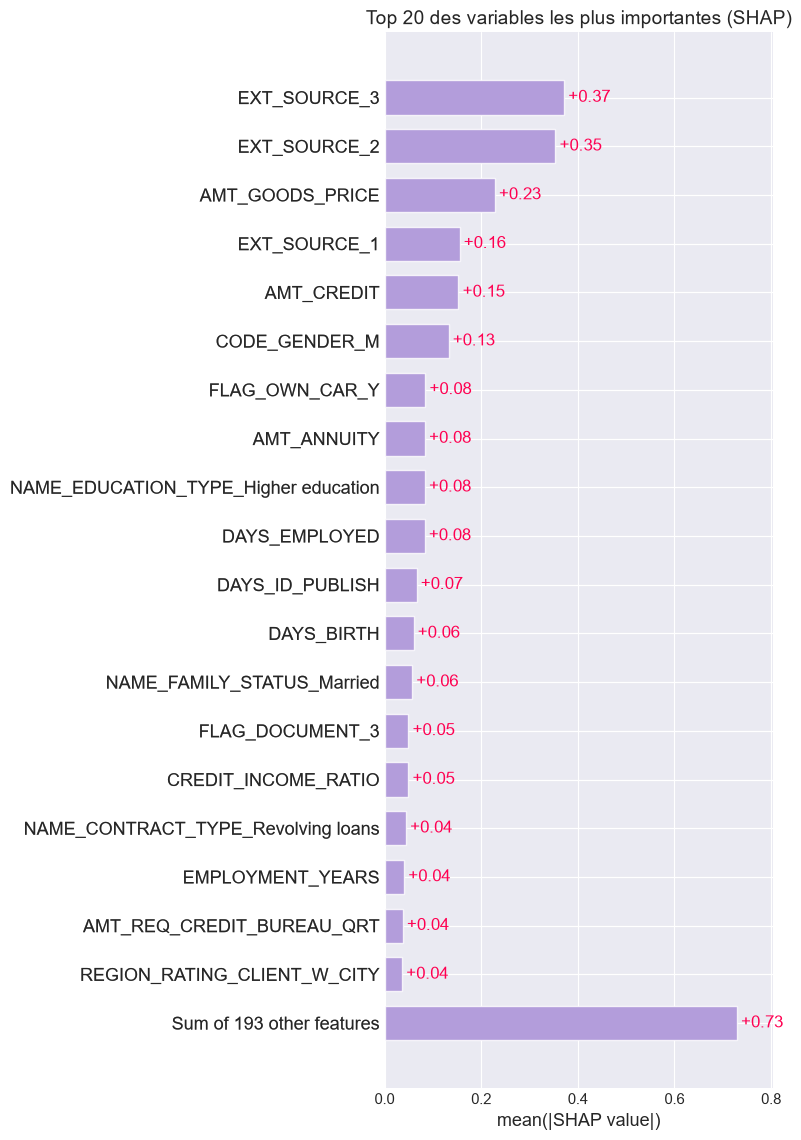

In [10]:
#bar plot
fig, ax = plt.subplots(figsize=(10, 8))
shap.plots.bar(
    shap.Explanation(
        values=shap_values,
        feature_names=X_sample.columns.tolist()
    ),
    max_display=20,
    show=False
)

for patch in plt.gca().patches:
    patch.set_facecolor('#B39DDB')

plt.title("Top 20 des variables les plus importantes (SHAP)", fontsize=14)
plt.tight_layout()
plt.savefig("../outputs/figures/13_shap_bar_plot.png", dpi=150, bbox_inches='tight')
plt.show()

Les EXT_SOURCE dominent massivement, comme dans le Random Forest mais contrairement à la régression logistique.

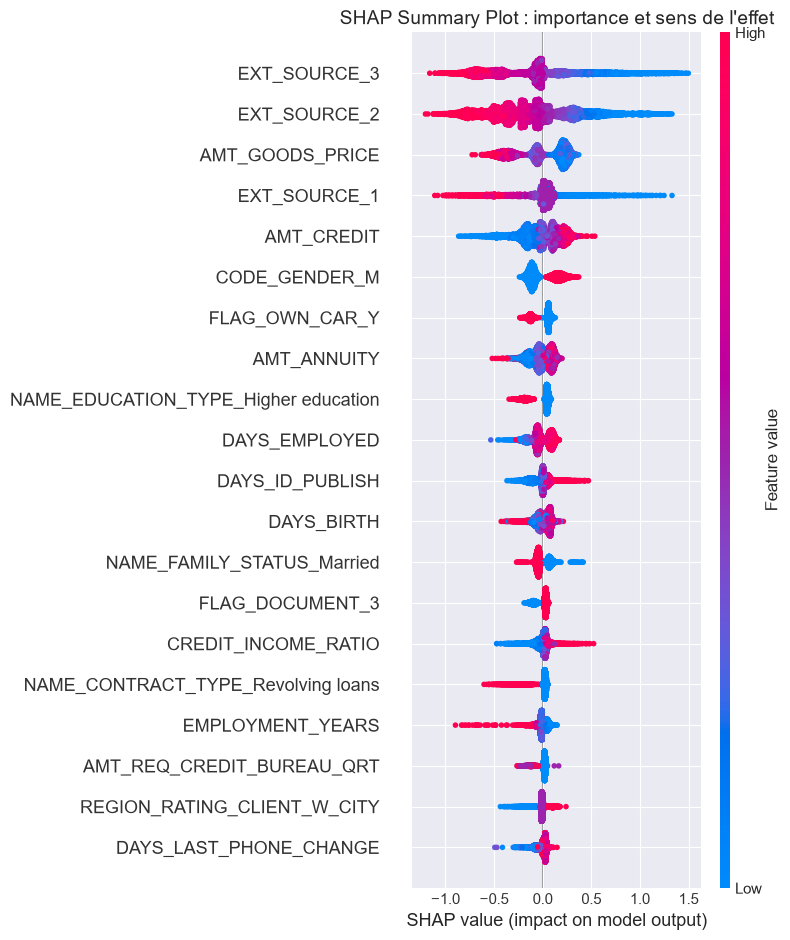

In [9]:
# Summary plot
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_sample,
    max_display=20,
    show=False
)
plt.title("SHAP Summary Plot : importance et sens de l'effet", fontsize=14)
plt.tight_layout()
plt.savefig("../outputs/figures/14_shap_summary_plot.png", dpi=150, bbox_inches='tight')
plt.show()

EXT_SOURCE_3 et EXT_SOURCE_2 : quand ces scores sont élevés, ils tirent la prédiction vers la gauche (diminuent le risque). Quand ils sont bas, ils augmentent le risque.

CODE_GENDER_M : être un homme augmente le risque.

NAME_EDUCATION_TYPE_Higher education : avoir un diplôme supérieur diminue le risque.

CREDIT_INCOME_RATIO : un ratio élevé augmente le risque, plus le crédit est lourd par rapport au revenu, plus le risque est élevé.

## 3. Comparaison SHAP vs coefficients régression logistique

Le classement des variables importantes diffère-t-il entre les deux approches ?
Si oui, qu'est-ce que XGBoost capture que la logistique ne voit pas ?

In [11]:
# Top 10 SHAP (XGBoost)
shap_importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_sample.columns
).sort_values(ascending=False)

# Top 10 coefficients logistique (depuis le Notebook 03)
from sklearn.linear_model import LogisticRegression
model_lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model_lr.fit(X_train, y_train)
lr_importance = pd.Series(
    np.abs(model_lr.coef_[0]),
    index=X_train.columns
).sort_values(ascending=False)

# Comparaison côte à côte
print(f"{'Rang':<6} {'SHAP (XGBoost)':<40} {'Coefficients (Logistique)':<40}")
print("-" * 86)
for i in range(10):
    shap_var = shap_importance.index[i]
    lr_var = lr_importance.index[i]
    print(f"{i+1:<6} {shap_var:<40} {lr_var:<40}")

Rang   SHAP (XGBoost)                           Coefficients (Logistique)               
--------------------------------------------------------------------------------------
1      EXT_SOURCE_3                             FLAG_DOCUMENT_2                         
2      EXT_SOURCE_2                             NAME_INCOME_TYPE_Unemployed             
3      AMT_GOODS_PRICE                          ORGANIZATION_TYPE_Trade: type 4         
4      EXT_SOURCE_1                             FLAG_DOCUMENT_15                        
5      AMT_CREDIT                               NAME_INCOME_TYPE_Pensioner              
6      CODE_GENDER_M                            AMT_GOODS_PRICE                         
7      FLAG_OWN_CAR_Y                           NAME_EDUCATION_TYPE_Lower secondary     
8      AMT_ANNUITY                              AMT_CREDIT                              
9      NAME_EDUCATION_TYPE_Higher education     FLAG_DOCUMENT_13                        
10     DAYS_EMPLOYED   

SHAP (XGBoost) privilégie les variables numériques continues (EXT_SOURCE, montants financiers, âge, ancienneté). Ce sont des variables à forte variance que les arbres exploitent bien via des seuils non-linéaires.

Régression logistique privilégie les variables binaires/catégorielles (FLAG_DOCUMENT, NAME_INCOME_TYPE, ORGANIZATION_TYPE). Ce sont des variables dont l'effet est directement capturable par un coefficient linéaire.

Seules AMT_GOODS_PRICE et AMT_CREDIT apparaissent dans les deux top 10. Ça montre que les deux modèles n'exploitent pas les mêmes signaux dans les données, ce qui explique en partie l'écart de performance.

## 4. Interprétabilité locale (3 clients)

Sélection de 3 clients représentatifs dans le test set :
- Un client à **haut risque** (probabilité de défaut élevée)
- Un client à **faible risque** (probabilité de défaut basse)
- Un **cas ambigu** (probabilité proche du seuil de 0.5)

Pour chacun, un waterfall plot SHAP décompose la prédiction variable par variable.

In [12]:
# Prédictions sur l'échantillon
y_pred_sample = model_xgb.predict_proba(X_sample)[:, 1]

# Client à haut risque (probabilité la plus élevée)
idx_haut_risque = y_pred_sample.argmax()

# Client à faible risque (probabilité la plus basse)
idx_faible_risque = y_pred_sample.argmin()

# Cas ambigu (probabilité la plus proche de 0.5)
idx_ambigu = np.abs(y_pred_sample - 0.5).argmin()

print(f"  Client HAUT RISQUE   (index {idx_haut_risque}) → probabilité de défaut : {y_pred_sample[idx_haut_risque]:.4f}")
print(f"  Client FAIBLE RISQUE (index {idx_faible_risque}) → probabilité de défaut : {y_pred_sample[idx_faible_risque]:.4f}")
print(f"  Client AMBIGU        (index {idx_ambigu}) → probabilité de défaut : {y_pred_sample[idx_ambigu]:.4f}")

  Client HAUT RISQUE   (index 1644) → probabilité de défaut : 0.9508
  Client FAIBLE RISQUE (index 8539) → probabilité de défaut : 0.0081
  Client AMBIGU        (index 7119) → probabilité de défaut : 0.5000


CLIENT HAUT RISQUE (probabilité de défaut : 0.9508)


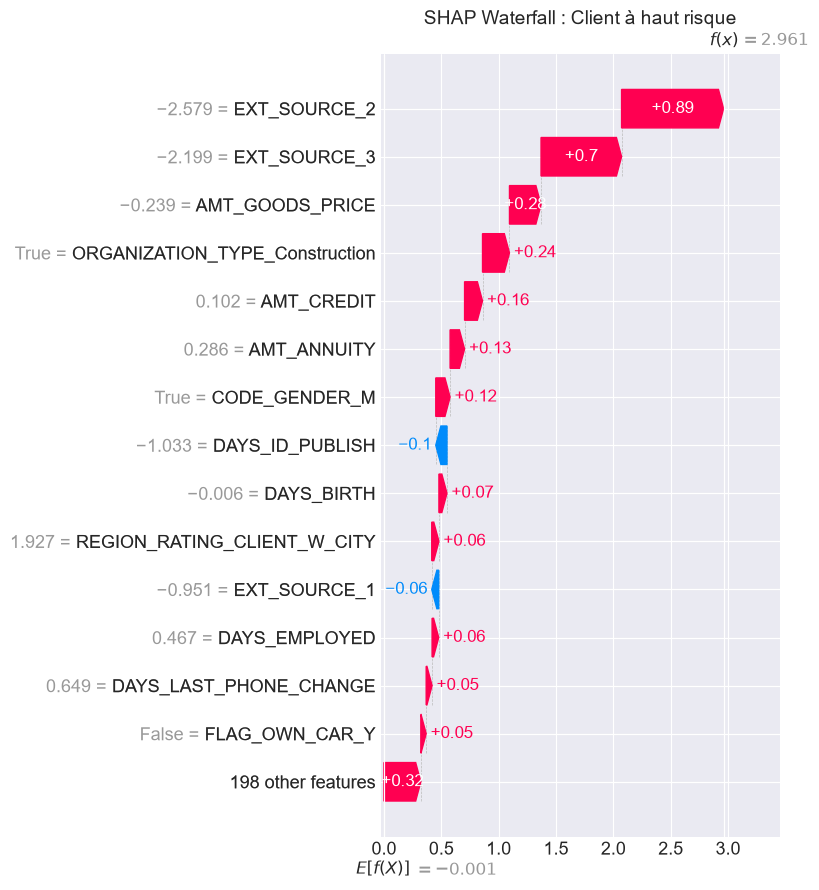

In [15]:
# waterfall du client à haut risque
shap_explanation = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=X_sample.values,
    feature_names=X_sample.columns.tolist()
)

print("CLIENT HAUT RISQUE (probabilité de défaut : 0.9508)")
fig, ax = plt.subplots(figsize=(10, 8))
shap.plots.waterfall(shap_explanation[idx_haut_risque], max_display=15, show=False)
plt.title("SHAP Waterfall : Client à haut risque", fontsize=14)
plt.tight_layout()
plt.savefig("../outputs/figures/15_shap_waterfall_haut_risque.png", dpi=150, bbox_inches='tight')
plt.show()

Ce client a un risque prédit de 95 % principalement parce que ses scores externes sont très bas (EXT_SOURCE_2 = -2.58 et EXT_SOURCE_3 = -2.20, soit les valeurs les plus risquées), il travaille dans le secteur de la construction, et c'est un homme. Presque toutes les variables poussent dans le même sens (risque). Seuls DAYS_ID_PUBLISH et EXT_SOURCE_1 le protègent légèrement.

CLIENT FAIBLE RISQUE (probabilité de défaut : 0.0081)


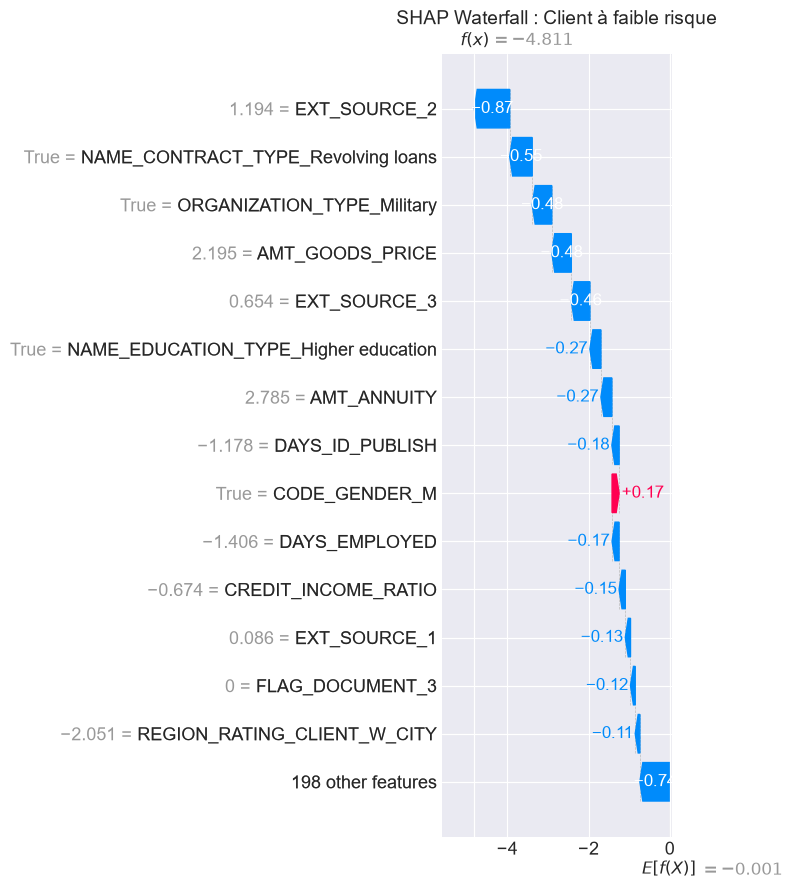

In [17]:
# waterfall du client à faible risque
print("CLIENT FAIBLE RISQUE (probabilité de défaut : 0.0081)")
fig, ax = plt.subplots(figsize=(10, 8))
shap.plots.waterfall(shap_explanation[idx_faible_risque], max_display=15, show=False)
plt.title("SHAP Waterfall : Client à faible risque", fontsize=14)
plt.tight_layout()
plt.savefig("../outputs/figures/16_shap_waterfall_faible_risque.png", dpi=150, bbox_inches='tight')
plt.show()

C'est un profil sûr, presque tout est bleu (protecteur) : EXT_SOURCE_2 élevé (-0.87), crédit revolving (-0.55), militaire (-0.44), diplôme supérieur (-0.27), bon ratio crédit/revenu (-0.15). Le seul facteur de risque est CODE_GENDER_M (+0.17), mais il est noyé par les protections.

CLIENT AMBIGU (probabilité de défaut : 0.5000)


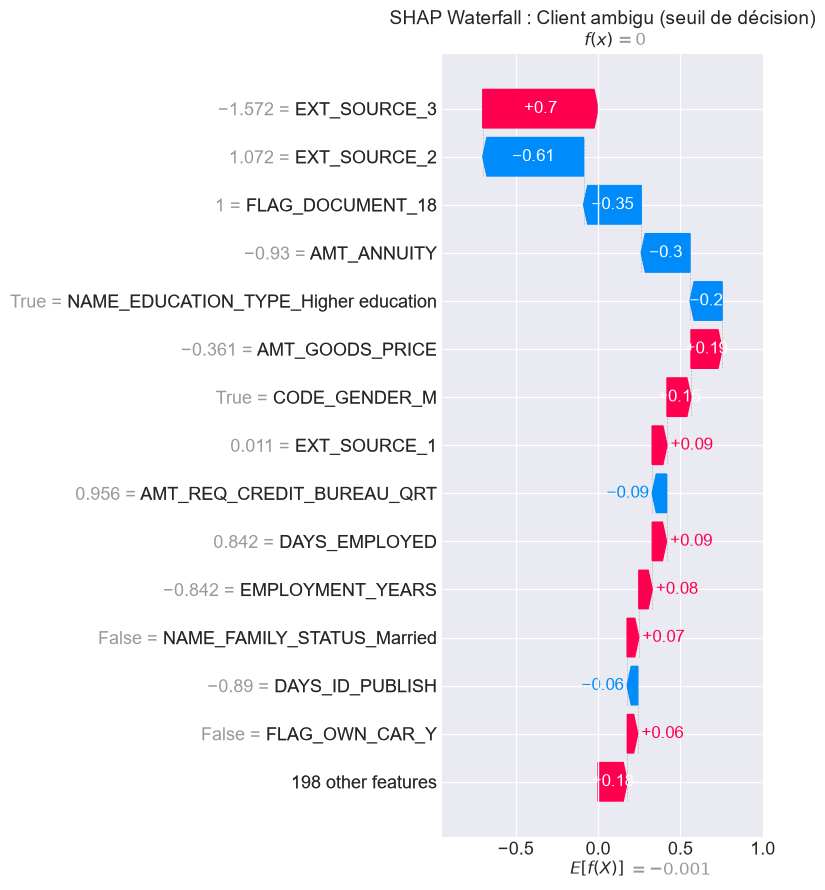

In [19]:
# waterfall du cas ambigu
print("CLIENT AMBIGU (probabilité de défaut : 0.5000)")
fig, ax = plt.subplots(figsize=(10, 8))
shap.plots.waterfall(shap_explanation[idx_ambigu], max_display=15, show=False)
plt.title("SHAP Waterfall : Client ambigu (seuil de décision)", fontsize=14)
plt.tight_layout()
plt.savefig("../outputs/figures/17_shap_waterfall_ambigu.png", dpi=150, bbox_inches='tight')
plt.show()

EXT_SOURCE_3 bas pousse vers le risque (+0.70), mais EXT_SOURCE_2 élevé protège (-0.61). Le diplôme supérieur (-0.20) et l'annuité basse (-0.30) protègent, mais le genre masculin (+0.10), le statut non-marié (+0.07) et l'absence de voiture (+0.06) poussent vers le risque.

## 5. Synthèse et discussion

### Interprétabilité globale

Les 3 variables les plus importantes selon SHAP sont EXT_SOURCE_3, EXT_SOURCE_2 
et AMT_GOODS_PRICE. Ce classement est similaire au Random Forest mais très 
différent de la régression logistique (qui privilégiait les FLAG_DOCUMENT et les 
variables catégorielles). Seules AMT_GOODS_PRICE et AMT_CREDIT apparaissent dans 
les deux top 10.

Le summary plot confirme que les relations apprises par XGBoost sont cohérentes 
avec l'intuition métier, des scores externes élevés protègent, un ratio 
crédit/revenu élevé augmente le risque, un diplôme supérieur protège.

### Interprétabilité locale (3 clients)

**Client à haut risque (95 %)** : scores externes très bas, secteur construction, 
homme. Presque toutes les variables convergent vers le risque.

**Client à faible risque (0,8 %)** : scores externes élevés, militaire, diplôme 
supérieur, crédit revolving, bon ratio crédit/revenu.

**Client ambigu (50 %)** : les forces s'annulent, EXT_SOURCE_3 bas pousse vers le 
risque, mais EXT_SOURCE_2 élevé et le diplôme supérieur protègent. SHAP rend 
cette incertitude transparente, ce qui est un argument en sa faveur pour la 
conformité réglementaire.

### Comparaison avec la régression logistique

- Les coefficients de la logistique offrent une interprétation **directe et native**
- SHAP offre une interprétation **post-hoc mais plus riche** : on voit les 
  non-linéarités, les interactions, et l'explication individualisée
- Les deux approches identifient des variables différentes comme importantes, 
  ce qui montre que XGBoost exploite des signaux que la logistique ne capte pas
- En revanche, SHAP reste une approximation car il explique ce que le modèle 
  semble faire, pas nécessairement ce qu'il fait réellement (Rudin, 2019)

### Réponse à la problématique

Le gain de XGBoost par rapport à la logistique est de +1.04 point d'AUC 
(0.7589 vs 0.7485). Ce gain est modeste. En contrepartie :
- SHAP produit des explications cohérentes avec le métier
- Les décisions extrêmes (haut risque, faible risque) sont bien explicables
- Les cas ambigus révèlent une incertitude que SHAP rend transparente

La question reste ouverte : ce niveau d'interprétabilité post-hoc suffit-il 
à satisfaire les exigences du RGPD (art. 22), de l'AI Act, et des orientations 
EBA ?